# Trainer

In [1]:
import copy
from sklearn.metrics import hamming_loss, f1_score
import torch
from torch import nn, optim
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt


class MultiLabelTrainer:
    """Trains and evaluates a multi-label model, following the ModelTrainer
    pattern from 3_Multilabel_classification.ipynb but adapted for
    BCEWithLogitsLoss and multi-label metrics."""

    def __init__(
        self,
        model: object,
        train_loader: DataLoader,
        val_loader: DataLoader,
        device: torch.device,
        lr: float = 1e-3,
        num_epochs: int = 100,
    ):
        self.model = model
        self.train_loader = train_loader
        self.val_loader = val_loader
        self.device = device
        self.lr = lr
        self.num_epochs = num_epochs

        self.criterion = nn.BCEWithLogitsLoss()
        self.optimizer = optim.Adam(self.model.parameters(), lr=lr)

        self.best_state = None
        self.history = {"train_loss": [], "val_loss": []}

    # ------ private helpers --------------------------------------------------

    def _train_one_epoch(self):
        self.model.train()
        running_loss = 0.0
        for X_b, y_b in self.train_loader:
            X_b, y_b = X_b.to(self.device), y_b.to(self.device)
            self.optimizer.zero_grad()
            loss = self.criterion(self.model(X_b), y_b)
            loss.backward()
            self.optimizer.step()
            running_loss += loss.item()
        return running_loss / len(self.train_loader)

    @torch.no_grad()
    def _calculate_val_loss(self):
        self.model.eval()
        running_loss = 0.0
        for X_b, y_b in self.val_loader:
            X_b, y_b = X_b.to(self.device), y_b.to(self.device)
            running_loss += self.criterion(self.model(X_b), y_b).item()
        return running_loss / len(self.val_loader)

    # ------ public API -------------------------------------------------------

    def train(self) -> dict:
        best_val_loss = float("inf")

        for epoch in range(self.num_epochs):
            train_loss = self._train_one_epoch()
            val_loss = self._calculate_val_loss()

            self.history["train_loss"].append(train_loss)
            self.history["val_loss"].append(val_loss)

            if val_loss < best_val_loss:
                best_val_loss = val_loss
                self.best_state = copy.deepcopy(self.model.state_dict())

        self.model.load_state_dict(self.best_state)
        print(f"Training done — best val loss: {best_val_loss:.4f}")
        return self.history

    @torch.no_grad()
    def evaluate(self, loader: DataLoader) -> dict:
        """Compute loss and multi-label metrics on an arbitrary loader."""
        self.model.eval()
        all_logits, all_targets = [], []

        running_loss = 0.0
        for X_b, y_b in loader:
            X_b, y_b = X_b.to(self.device), y_b.to(self.device)
            logits = self.model(X_b)
            running_loss += self.criterion(logits, y_b).item()
            all_logits.append(logits.cpu())
            all_targets.append(y_b.cpu())

        logits = torch.cat(all_logits)
        targets = torch.cat(all_targets).numpy().astype(int)
        preds = (torch.sigmoid(logits) > 0.5).numpy().astype(int)

        return {
            "loss":         running_loss / len(loader),
            "hamming_loss": hamming_loss(targets, preds),
            "micro_f1":     f1_score(targets, preds, average="micro", zero_division=0),
            "macro_f1":     f1_score(targets, preds, average="macro", zero_division=0),
        }

    @staticmethod
    def plot_loss(history: dict, title: str = ""):
        plt.figure(figsize=(8, 4))
        plt.plot(history["train_loss"], label="Train")
        plt.plot(history["val_loss"],   label="Val")
        plt.xlabel("Epoch")
        plt.ylabel("BCEWithLogitsLoss")
        plt.title(f"Loss curve — {title}" if title else "Loss curve")
        plt.legend()
        plt.tight_layout()
        plt.show()

# Data

In [2]:
import numpy as np
import openml

dataset = openml.datasets.get_dataset(312)
X, _, _, _ = dataset.get_data(target=None)
label_cols = ["Beach", "Sunset", "FallFoliage", "Field", "Mountain", "Urban"]
attr_cols = [col for col in X.columns if 'attr' in col]
y = X[label_cols].values.astype(np.float32)
X = X[attr_cols]

X.shape

(2407, 294)

In [3]:
import torch
from torch import nn, optim
from torch.utils.data import TensorDataset, DataLoader
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import pandas as pd

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# --- Standardize features ---
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X.values).astype(np.float32)

# --- Train (60%) / Val (20%) / Test (20%) ---
X_train, X_temp, y_train, y_temp = train_test_split(
    X_scaled, y, test_size=0.4, random_state=42
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42
)

print(f"Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}")

# --- DataLoaders ---
BATCH_SIZE = 64

train_ds = TensorDataset(torch.from_numpy(X_train), torch.from_numpy(y_train))
val_ds   = TensorDataset(torch.from_numpy(X_val),   torch.from_numpy(y_val))
test_ds  = TensorDataset(torch.from_numpy(X_test),  torch.from_numpy(y_test))

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_ds,   batch_size=len(val_ds))
test_loader  = DataLoader(test_ds,  batch_size=len(test_ds))

INPUT_DIM  = X_train.shape[1]
N_LABELS   = y_train.shape[1]
print(f"Input dim: {INPUT_DIM}, Labels: {N_LABELS}")

Train: (1444, 294), Val: (481, 294), Test: (482, 294)
Input dim: 294, Labels: 6


# Architectures and Models

In [4]:
from torch import nn

class SharedOutputMLP(nn.Module):
    """MLP with a shared body and a single linear output layer for all labels."""

    def __init__(self, input_dim, hidden_dim, n_hidden, n_labels, activation="ReLU"):
        super().__init__()
        self.input_layer = nn.Linear(input_dim, hidden_dim)
        self.hidden_layers = nn.ModuleList(
            [nn.Linear(hidden_dim, hidden_dim) for _ in range(n_hidden)]
        )
        self.output_layer = nn.Linear(hidden_dim, n_labels)

        self.activation = nn.ReLU() if activation == "ReLU" else nn.Tanh()

    def forward(self, x):
        x = self.activation(self.input_layer(x))
        for layer in self.hidden_layers:
            x = self.activation(layer(x))
        return self.output_layer(x)  # raw logits

class Pyramid(nn.Module):
    """
    MLP with a pyramid architecture:
    input -> 2*input -> 4*input ... -> 4*output -> 2*output -> output
    """

    def __init__(self, input_dim, output_dim, n_expansion_steps=2, activation="ReLU"):
        super().__init__()

        self.activation = nn.ReLU() if activation == "ReLU" else nn.Tanh()
        layers = []

        # 1. Expansion Phase: input -> ... -> peak
        current_dim = input_dim
        for _ in range(n_expansion_steps):
            next_dim = current_dim * 2
            layers.append(nn.Linear(current_dim, next_dim))
            layers.append(self.activation)
            current_dim = next_dim

        # 2. Contraction Phase: peak -> ... -> output_dim
        target_peak_down = output_dim * (2 ** n_expansion_steps)

        # Connect the expansion peak to the contraction peak if they differ
        if current_dim != target_peak_down:
            layers.append(nn.Linear(current_dim, target_peak_down))
            layers.append(self.activation)
            current_dim = target_peak_down

        for _ in range(n_expansion_steps):
            next_dim = current_dim // 2
            layers.append(nn.Linear(current_dim, next_dim))
            # Only add activation if it's not the final output layer
            if next_dim != output_dim:
                layers.append(self.activation)
            current_dim = next_dim

        self.network = nn.Sequential(*layers)

    def forward(self, x):
        return self.network(x)



In [7]:
def total_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

pyramid_m = Pyramid(INPUT_DIM, N_LABELS, 2).to(DEVICE)
long_narrow = SharedOutputMLP(INPUT_DIM,  260, 12, N_LABELS).to(DEVICE)
wide_short = SharedOutputMLP(INPUT_DIM, 499,  3, N_LABELS).to(DEVICE)



print(f'Pyramid: {total_params(pyramid_m)} parameters')
print(f'long_narrow: {total_params(long_narrow)} parameters')
print(f'wide_short: {total_params(wide_short)} parameters')

Pyramid: 894750 parameters
long_narrow: 892586 parameters
wide_short: 898705 parameters


# Train and BenchMark


=== Pyramid Model ===
Training done — best val loss: 0.2218


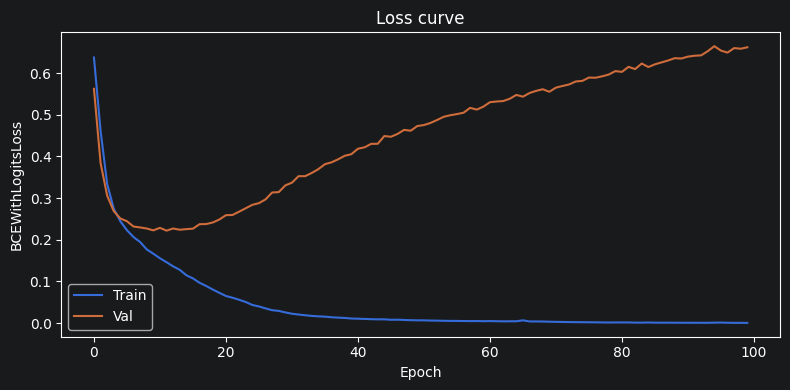

{'loss': 0.20210164785385132, 'hamming_loss': 0.08022130013831259, 'micro_f1': 0.7603305785123967, 'macro_f1': 0.7662267249146201}

=== Long Model ===
Training done — best val loss: 0.3042


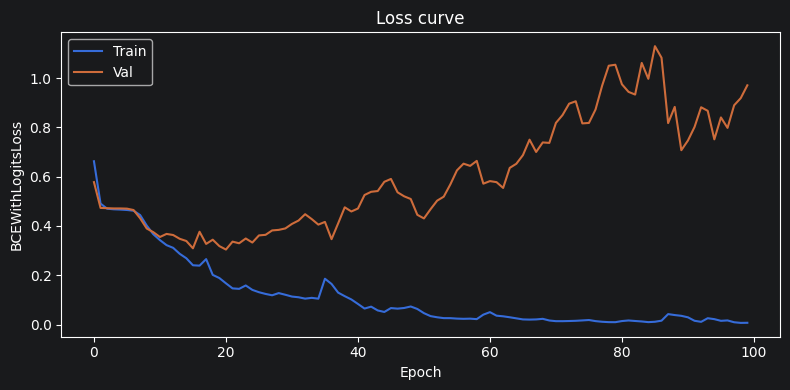

{'loss': 0.30214303731918335, 'hamming_loss': 0.1037344398340249, 'micro_f1': 0.6666666666666666, 'macro_f1': 0.6277299810661897}

=== Wide Short Model ===
Training done — best val loss: 0.2062


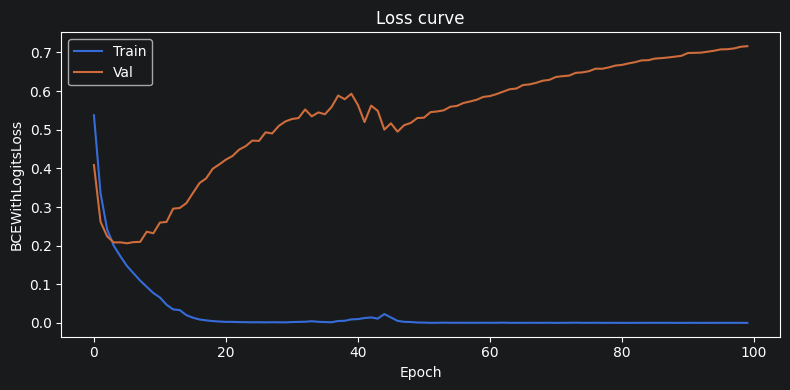

{'loss': 0.18389132618904114, 'hamming_loss': 0.07918395573997233, 'micro_f1': 0.7626943005181347, 'macro_f1': 0.7681443772155312}


In [8]:
pyramid_trainer = MultiLabelTrainer(pyramid_m, train_loader, val_loader, DEVICE, 3e-4, 100)
long_trainer = MultiLabelTrainer(long_narrow, train_loader, val_loader, DEVICE, 3e-4, 100)
wide_tainer = MultiLabelTrainer(wide_short, train_loader, val_loader, DEVICE, 3e-4, 100)

print(f'\n=== Pyramid Model ===')
history = pyramid_trainer.train()
pyramid_trainer.plot_loss(history)
pyramid_score  = pyramid_trainer.evaluate(test_loader)
print(pyramid_score)

print(f'\n=== Long Model ===')
history = long_trainer.train()
long_trainer.plot_loss(history)
long_score = long_trainer.evaluate(test_loader)
print(long_score)

print(f'\n=== Wide Short Model ===')
history = wide_tainer.train()
wide_tainer.plot_loss(history)
wide_score = wide_tainer.evaluate(test_loader)
print(wide_score)
